# Proyek Klasifikasi Gambar: Hewan
- **Nama:** [Nadira Atshifa Rinjani]
- **Email:** [nadiraasf19@gmail.com]
- **ID Dicoding:** [M891D5X1430]

## Import Semua Packages/Library yang Digunakan

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt

## Data Preparation

### Data Loading

In [2]:
from google.colab import drive
drive.mount('/content/drive')
shared_folder_path = '/content/drive/MyDrive/Project Akhir Deep Learning_ASAH DICODING/Dataset hewan'
import os
print(os.listdir(shared_folder_path))


Mounted at /content/drive
['horse', 'spider', 'fish', 'chicken', 'dog', 'cat', 'butterfly']


### Data Preprocessing

#### Split Dataset

In [3]:
pip install split-folders

In [5]:
import splitfolders

input_folder = '/content/drive/MyDrive/Project Akhir Deep Learning_ASAH DICODING/Dataset hewan'
output_folder = '/content/drive/MyDrive/Project Akhir Deep Learning_ASAH DICODING/Dataset_split'

# 70% train, 20% val, 10% test
splitfolders.ratio(input_folder, output=output_folder, seed=1337, ratio=(0.7, 0.2, 0.1))

Copying files: 10498 files [07:06, 24.62 files/s]


In [8]:
base_dir = '/content/drive/MyDrive/Project Akhir Deep Learning_ASAH DICODING/Dataset_split'

# Data generator untuk TRAIN
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True,
    brightness_range=[0.7, 1.3]
)

# Data generator untuk VALIDATION & TEST
test_val_datagen = ImageDataGenerator(rescale=1./255)

# Buat generator dari masing-masing folder
train_gen = train_datagen.flow_from_directory(
    base_dir + '/train',
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical'
)

val_gen = test_val_datagen.flow_from_directory(
    base_dir + '/val',
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

test_gen = test_val_datagen.flow_from_directory(
    base_dir + '/test',
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Cek jumlah data dan kelas
num_classes = train_gen.num_classes
print("Jumlah data train:", train_gen.samples)
print("Jumlah data val:", val_gen.samples)
print("Jumlah data test:", test_gen.samples)
print("Jumlah kelas:", num_classes)

Found 7345 images belonging to 7 classes.
Found 2096 images belonging to 7 classes.
Found 1057 images belonging to 7 classes.
Jumlah data train: 7345
Jumlah data val: 2096
Jumlah data test: 1057
Jumlah kelas: 7


## Modelling

In [10]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout, BatchNormalization

base_model = MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

model = Sequential([
    base_model,
    Conv2D(256, (3,3), activation='relu', padding='same'),  # Tambahan Conv2D
    BatchNormalization(),
    MaxPooling2D(2,2),
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(num_classes, activation='softmax')
])

# Compile
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 256)      │     2,949,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,275,975 (20.13 MB)

 Trainable params: 3,017,479 (11.51 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

In [11]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, verbose=1)
checkpoint = ModelCheckpoint('best_model_mobilenetv2.h5', monitor='val_accuracy', save_best_only=True, verbose=1)

# Training
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 893ms/step - accuracy: 0.7835 - loss: 0.6940
Epoch 1: val_accuracy improved from -inf to 0.93177, saving model to best_model_mobilenetv2.h5


230/230 ━━━━━━━━━━━━━━━━━━━━ 257s 1s/step - accuracy: 0.7838 - loss: 0.6931 - val_accuracy: 0.9318 - val_loss: 0.2014 - learning_rate: 0.0010
Epoch 2/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 837ms/step - accuracy: 0.8898 - loss: 0.3328
Epoch 2: val_accuracy improved from 0.93177 to 0.93750, saving model to best_model_mobilenetv2.h5


230/230 ━━━━━━━━━━━━━━━━━━━━ 228s 992ms/step - accuracy: 0.8898 - loss: 0.3328 - val_accuracy: 0.9375 - val_loss: 0.1761 - learning_rate: 0.0010
Epoch 3/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 800ms/step - accuracy: 0.9027 - loss: 0.2870
Epoch 3: val_accuracy did not improve from 0.93750
230/230 ━━━━━━━━━━━━━━━━━━━━ 222s 961ms/step - accuracy: 0.9028 - loss: 0.2870 - val_accuracy: 0.9270 - val_loss: 0.2322 - learning_rate: 0.0010
Epoch 4/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 822ms/step - accuracy: 0.9068 - loss: 0.2690
Epoch 4: val_accuracy did not improve from 0.93750
230/230 ━━━━━━━━━━━━━━━━━━━━ 225s 977ms/step - accuracy: 0.9068 - loss: 0.2691 - val_accuracy: 0.9251 - val_loss: 0.2162 - learning_rate: 0.0010
Epoch 5/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 803ms/step - accuracy: 0.9142 - loss: 0.2476
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.

Epoch 5: val_accuracy did not improve from 0.93750
230/230 ━━━━━━━━━━━━━━━━━━━━ 222s 964ms/step - accuracy: 0.9142 - loss

230/230 ━━━━━━━━━━━━━━━━━━━━ 237s 1s/step - accuracy: 0.9155 - loss: 0.2388 - val_accuracy: 0.9461 - val_loss: 0.1611 - learning_rate: 2.0000e-04
Epoch 7/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 813ms/step - accuracy: 0.9231 - loss: 0.2191
Epoch 7: val_accuracy did not improve from 0.94609
230/230 ━━━━━━━━━━━━━━━━━━━━ 225s 978ms/step - accuracy: 0.9232 - loss: 0.2190 - val_accuracy: 0.9447 - val_loss: 0.1764 - learning_rate: 2.0000e-04
Epoch 8/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 820ms/step - accuracy: 0.9363 - loss: 0.1842
Epoch 8: val_accuracy did not improve from 0.94609
230/230 ━━━━━━━━━━━━━━━━━━━━ 227s 986ms/step - accuracy: 0.9363 - loss: 0.1843 - val_accuracy: 0.9451 - val_loss: 0.1658 - learning_rate: 2.0000e-04
Epoch 9/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 860ms/step - accuracy: 0.9380 - loss: 0.1880
Epoch 9: ReduceLROnPlateau reducing learning rate to 4.0000001899898055e-05.

Epoch 9: val_accuracy did not improve from 0.94609
230/230 ━━━━━━━━━━━━━━━━━━━━ 239s 1s/step - accuracy: 0.9380 

230/230 ━━━━━━━━━━━━━━━━━━━━ 224s 972ms/step - accuracy: 0.9375 - loss: 0.1910 - val_accuracy: 0.9490 - val_loss: 0.1525 - learning_rate: 4.0000e-05
Epoch 11/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 809ms/step - accuracy: 0.9375 - loss: 0.1913
Epoch 11: val_accuracy did not improve from 0.94895
230/230 ━━━━━━━━━━━━━━━━━━━━ 223s 971ms/step - accuracy: 0.9375 - loss: 0.1912 - val_accuracy: 0.9470 - val_loss: 0.1578 - learning_rate: 4.0000e-05
Epoch 12/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 845ms/step - accuracy: 0.9398 - loss: 0.1788
Epoch 12: val_accuracy improved from 0.94895 to 0.94990, saving model to best_model_mobilenetv2.h5


230/230 ━━━━━━━━━━━━━━━━━━━━ 231s 1s/step - accuracy: 0.9398 - loss: 0.1788 - val_accuracy: 0.9499 - val_loss: 0.1538 - learning_rate: 4.0000e-05
Epoch 13/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 821ms/step - accuracy: 0.9437 - loss: 0.1666
Epoch 13: ReduceLROnPlateau reducing learning rate to 8.000000525498762e-06.

Epoch 13: val_accuracy improved from 0.94990 to 0.95038, saving model to best_model_mobilenetv2.h5


230/230 ━━━━━━━━━━━━━━━━━━━━ 225s 976ms/step - accuracy: 0.9437 - loss: 0.1667 - val_accuracy: 0.9504 - val_loss: 0.1548 - learning_rate: 4.0000e-05
Epoch 14/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 806ms/step - accuracy: 0.9380 - loss: 0.1798
Epoch 14: val_accuracy did not improve from 0.95038
230/230 ━━━━━━━━━━━━━━━━━━━━ 268s 1s/step - accuracy: 0.9380 - loss: 0.1797 - val_accuracy: 0.9485 - val_loss: 0.1563 - learning_rate: 8.0000e-06
Epoch 15/15
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 804ms/step - accuracy: 0.9430 - loss: 0.1733
Epoch 15: val_accuracy did not improve from 0.95038
230/230 ━━━━━━━━━━━━━━━━━━━━ 222s 965ms/step - accuracy: 0.9430 - loss: 0.1733 - val_accuracy: 0.9485 - val_loss: 0.1562 - learning_rate: 8.0000e-06


## Evaluasi dan Visualisasi

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


34/34 ━━━━━━━━━━━━━━━━━━━━ 21s 609ms/step - accuracy: 0.9618 - loss: 0.1182

Test Accuracy: 0.9451
Test Loss: 0.1721


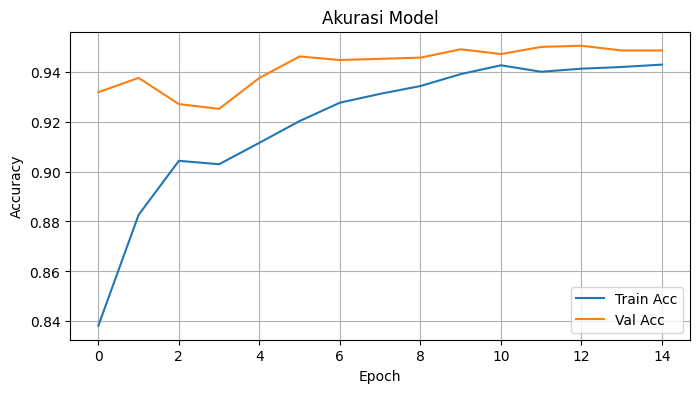

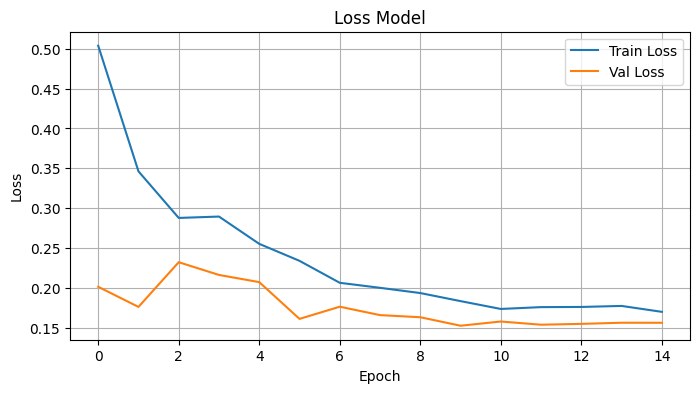

34/34 ━━━━━━━━━━━━━━━━━━━━ 21s 565ms/step


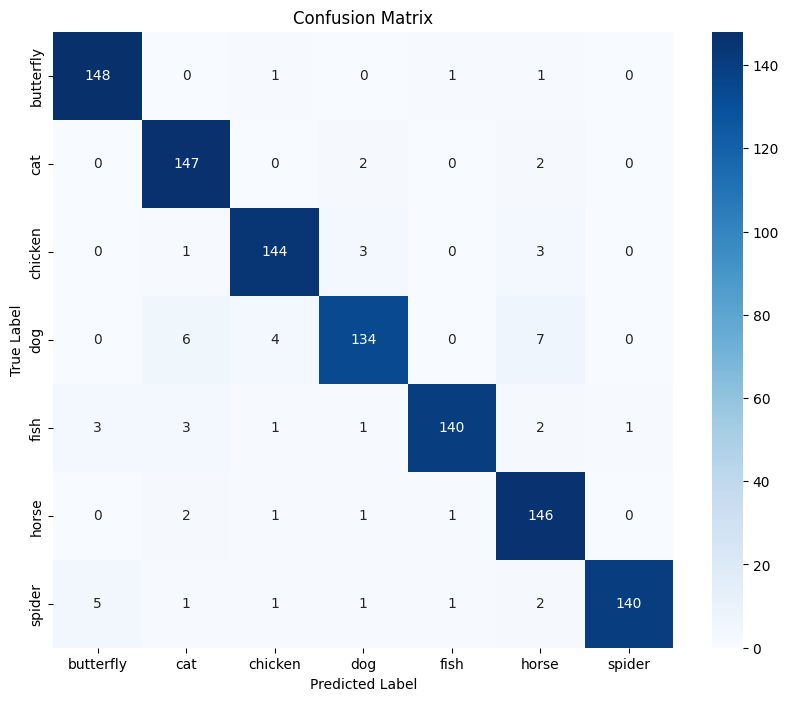


Classification Report:
              precision    recall  f1-score   support

   butterfly       0.95      0.98      0.96       151
         cat       0.92      0.97      0.95       151
     chicken       0.95      0.95      0.95       151
         dog       0.94      0.89      0.91       151
        fish       0.98      0.93      0.95       151
       horse       0.90      0.97      0.93       151
      spider       0.99      0.93      0.96       151

    accuracy                           0.95      1057
   macro avg       0.95      0.95      0.95      1057
weighted avg       0.95      0.95      0.95      1057



In [12]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Evaluasi di test set
test_loss, test_acc = model.evaluate(test_gen)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Visualisasi Akurasi
plt.figure(figsize=(8,4))
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Akurasi Model')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Visualisasi Loss
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Model')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Confusion Matrix
y_true = test_gen.classes
y_pred = model.predict(test_gen)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(test_gen.class_indices.keys()),
            yticklabels=list(test_gen.class_indices.keys()))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Laporan klasifikasi
print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=list(test_gen.class_indices.keys())))


## Konversi Model

In [14]:
!pip install tensorflowjs

import tensorflowjs as tfjs
import os
import json

In [15]:
os.makedirs("saved_model", exist_ok=True)
os.makedirs("tflite", exist_ok=True)
os.makedirs("tfjs_model", exist_ok=True)

In [16]:
# Simpan model ke format SavedModel
model.export("saved_model")

print("Model disimpan ke format SavedModel di folder 'saved_model/'")


Saved artifact at 'saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='keras_tensor_315')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  135336259585808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135336259590608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135336259590416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135336259586960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135336259591184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135336259587728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135336259590800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135336259590992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135336259590032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135336259592144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135336259591568

In [17]:
# Konversi ke TFLite
converter = tf.lite.TFLiteConverter.from_saved_model("saved_model")
tflite_model = converter.convert()

# Simpan model TFLite
tflite_path = "tflite/model.tflite"
with open(tflite_path, "wb") as f:
    f.write(tflite_model)

# Simpan label kelas (nama folder dari train_generator)
labels = list(train_gen.class_indices.keys())
with open("tflite/label.txt", "w") as f:
    for label in labels:
        f.write(f"{label}\n")

print("Model dikonversi ke TensorFlow Lite di folder 'tflite/'")


Model dikonversi ke TensorFlow Lite di folder 'tflite/'


In [18]:
# Konversi ke TFJS
tfjs.converters.save_keras_model(model, "tfjs_model")

# Simpan label sebagai JSON
with open("tfjs_model/labels.json", "w") as f:
    json.dump(labels, f)

print("Model dikonversi ke TensorFlow.js di folder 'tfjs_model/'")


failed to lookup keras version from the file,
    this is likely a weight only file
Model dikonversi ke TensorFlow.js di folder 'tfjs_model/'


## Inference (Optional)

In [19]:
import numpy as np
from tensorflow.keras.preprocessing import image

img_path = "/content/drive/MyDrive/Project Akhir Deep Learning_ASAH DICODING/img1.jpeg"

# Preprocessing gambar
img = image.load_img(img_path, target_size=(128, 128))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Prediksi
pred = model.predict(img_array)
class_idx = np.argmax(pred)
class_label = list(train_gen.class_indices.keys())[class_idx]

print(f"Prediksi model: {class_label} ({pred[0][class_idx]*100:.2f}% confident)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Prediksi model: butterfly (99.99% confident)


In [20]:
import numpy as np
from tensorflow.keras.preprocessing import image

img_path = "/content/drive/MyDrive/Project Akhir Deep Learning_ASAH DICODING/img2.jpg"

# Preprocessing gambar
img = image.load_img(img_path, target_size=(128, 128))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Prediksi
pred = model.predict(img_array)
class_idx = np.argmax(pred)
class_label = list(train_gen.class_indices.keys())[class_idx]

print(f"Prediksi model: {class_label} ({pred[0][class_idx]*100:.2f}% confident)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
Prediksi model: horse (100.00% confident)


In [21]:
!pip freeze > requirements.txt

In [22]:
%%writefile README.md

## Dataset
- Jumlah total gambar: ±10.000
- Jumlah kelas: 7
- Setiap kelas berisi 1.498 gambar (seimbang)
- Dataset bersih dan bervariasi (tidak ada noise)
- Pembagian data:
  - **Training:** 70%
  - **Validation:** 20%
  - **Testing:** 10%
- Augmentasi dilakukan secara real-time menggunakan `ImageDataGenerator`:
  - Rescale (1./255)
  - Rotation (±30°)
  - Width & Height Shift (0.2)
  - Zoom (0.3)
  - Horizontal Flip
  - Brightness Range [0.7, 1.3]

## Model Architecture
Model menggunakan **Transfer Learning dengan MobileNetV2** dan **tambahan CNN layer**
Arsitektur Utama:
1. **Base Model:** MobileNetV2
2. **Conv2D + BatchNormalization + MaxPooling2D**
3. **GlobalAveragePooling2D**
4. **Dense(256, ReLU)** + **Dropout(0.4)**
5. **Output Layer:** Dense(num_classes, Softmax)

## Training Result
- **Akurasi Training:** ~94.3%
- **Akurasi Validation:** ~94.85%
- **Akurasi Testing:** ~94.51%
- **Loss Validation:** 0.1562
- **Loss Testing:** 0.1721
- Tidak terdapat overfitting signifikan
- Callback:
  - EarlyStopping
  - ReduceLROnPlateau
  - ModelCheckpoint

Tampilan grafik akurasi dan loss menunjukkan model belajar dengan stabil dan konvergen.

## Model Export
Model disimpan dalam tiga format:
| Format | Lokasi |
|---------|---------|
| SavedModel | `/saved_model/` |
| TensorFlow Lite | `/tflite/model.tflite` |
| TensorFlow.js | `/tfjs_model/model.json` |

## Inference (Uji Coba)
Model diuji dengan gambar baru menggunakan format **TFLite** untuk memastikan hasil inferensi sesuai dengan label sebenarnya.



Writing README.md


## Buat Folder ZIP


In [25]:
# 1. Buat folder utama 'submission'
!mkdir submission

!mv tfjs_model submission/
!mv tflite submission/
!mv saved_model submission/

!cp README.md submission/README.md
!cp requirements.txt submission/requirements.txt

!zip -r "Nadira Atshifa Rinjani_Klasifikasi Gambar.zip" submission/

  adding: submission/ (stored 0%)
  adding: submission/saved_model/ (stored 0%)
  adding: submission/saved_model/fingerprint.pb (stored 0%)
  adding: submission/saved_model/assets/ (stored 0%)
  adding: submission/saved_model/variables/ (stored 0%)
  adding: submission/saved_model/variables/variables.index (deflated 78%)
  adding: submission/saved_model/variables/variables.data-00000-of-00001 (deflated 7%)
  adding: submission/saved_model/saved_model.pb (deflated 91%)
  adding: submission/README.md (deflated 44%)
  adding: submission/requirements.txt (deflated 58%)
  adding: submission/tfjs_model/ (stored 0%)
  adding: submission/tfjs_model/group1-shard5of6.bin (deflated 7%)
  adding: submission/tfjs_model/labels.json (deflated 17%)
  adding: submission/tfjs_model/model.json (deflated 97%)
  adding: submission/tfjs_model/group1-shard4of6.bin (deflated 7%)
  adding: submission/tfjs_model/group1-shard2of6.bin (deflated 7%)
  adding: submission/tfjs_model/group1-shard3of6.bin (deflated 7%

In [26]:
from google.colab import files
files.download("Nadira Atshifa Rinjani_Klasifikasi Gambar.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>